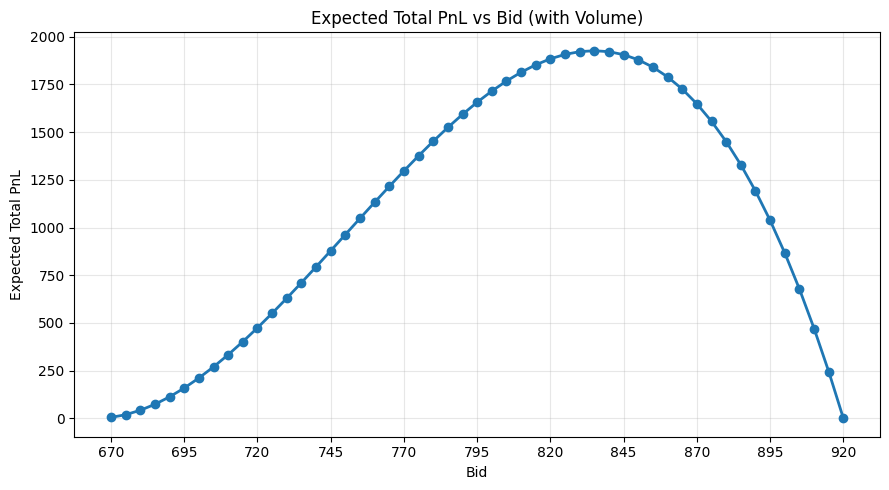

Best bid on this grid: 835
Volume at best bid: 34
Max expected total PnL: 1926.6667


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Discrete reserve prices: 670, 675, ..., 920 (uniform mass on each point)
reserves = np.arange(670, 925, 5)
bids = np.arange(670, 925, 5)

n = len(reserves)
expected_total_pnl = []
volumes = []

for b in bids:
    # User-specified volume rule, shifted so bid=670 gives volume=1
    volume = (b - 670) // 5 + 1
    volumes.append(volume)

    # Probability a random counterparty's reserve is <= bid
    trade_prob = np.sum(reserves <= b) / n

    pnl_per_filled_unit = 920 - b

    # Expected total PnL with volume and fill probability
    expected_total_pnl.append(volume * trade_prob * pnl_per_filled_unit)

plt.figure(figsize=(9, 5))
plt.plot(bids, expected_total_pnl, marker='o', linewidth=2)
plt.title('Expected Total PnL vs Bid (with Volume)')
plt.xlabel('Bid')
plt.ylabel('Expected Total PnL')
plt.grid(alpha=0.3)
plt.xticks(np.arange(670, 925, 25))
plt.tight_layout()
plt.show()

best_idx = int(np.argmax(expected_total_pnl))
print(f"Best bid on this grid: {bids[best_idx]}")
print(f"Volume at best bid: {volumes[best_idx]:.0f}")
print(f"Max expected total PnL: {expected_total_pnl[best_idx]:.4f}")

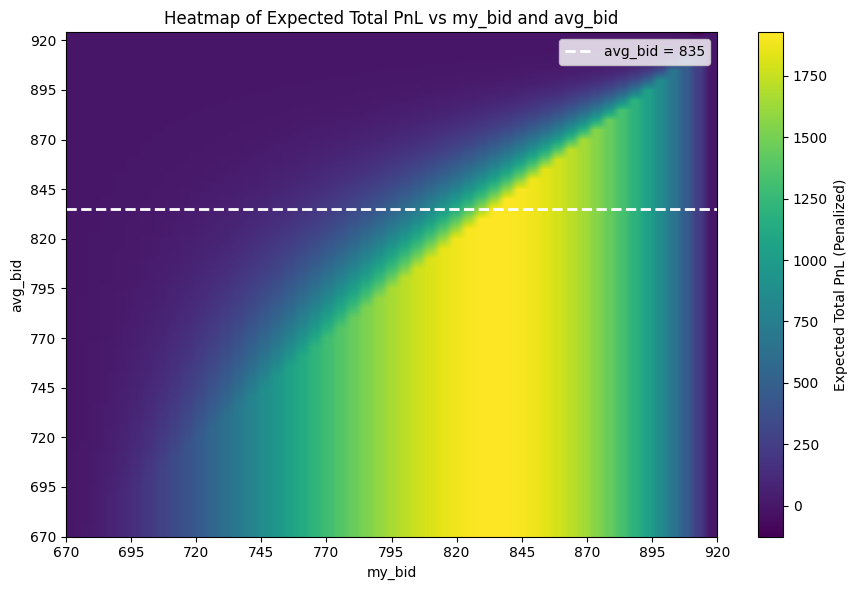

Best my_bid: 835
Best avg_bid: 670
Max penalized expected total PnL: 1926.6667


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Bid grids (increments of 5)
my_bids = np.arange(670, 925, 5)
avg_bids = np.arange(670, 925, 1)
reserves = np.arange(670, 925, 5)
n = len(reserves)

heatmap = np.zeros((len(avg_bids), len(my_bids)))

for i, avg_bid in enumerate(avg_bids):
    for j, bid in enumerate(my_bids):
        # Same base expected PnL logic as before
        volume = (bid - 670) // 5 + 1
        trade_prob = np.sum(reserves <= bid) / n
        pnl_per_filled_unit = 920 - bid
        base_expected_pnl = volume * trade_prob * pnl_per_filled_unit

        # Penalty factor: min(1, ((920-avg_bid)/(920-bid))^3)
        if bid >= 920:
            penalty = 1.0
        else:
            penalty = min(1.0, ((920 - avg_bid) / (920 - bid)) ** 3)

        heatmap[i, j] = base_expected_pnl * penalty

plt.figure(figsize=(9, 6))
img = plt.imshow(
    heatmap,
    origin='lower',
    aspect='auto',
    extent=[my_bids.min(), my_bids.max(), avg_bids.min(), avg_bids.max()],
    cmap='viridis'
)
plt.colorbar(img, label='Expected Total PnL (Penalized)')
plt.title('Heatmap of Expected Total PnL vs my_bid and avg_bid')
plt.xlabel('my_bid')
plt.ylabel('avg_bid')
plt.axhline(835, color='white', linestyle='--', linewidth=2, label='avg_bid = 835')
plt.legend(loc='upper right')
plt.xticks(np.arange(670, 925, 25))
plt.yticks(np.arange(670, 925, 25))
plt.tight_layout()
plt.show()

max_idx = np.unravel_index(np.argmax(heatmap), heatmap.shape)
print(f"Best my_bid: {my_bids[max_idx[1]]}")
print(f"Best avg_bid: {avg_bids[max_idx[0]]}")
print(f"Max penalized expected total PnL: {heatmap[max_idx]:.4f}")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# Plot min(1, ((920-avg)/(920-bid))^3) for a chosen avg_bid
bid_grid = np.arange(670, 921, 1)


def penalty_curve(avg_bid: int):
    with np.errstate(divide='ignore', invalid='ignore'):
        raw = ((920 - avg_bid) / (920 - bid_grid)) ** 3

    penalty = np.minimum(1.0, raw)
    penalty = np.where(bid_grid >= 920, 1.0, penalty)

    plt.figure(figsize=(9, 5))
    plt.plot(bid_grid, penalty, linewidth=2)
    plt.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    plt.title(f'Penalty Factor vs bid (avg_bid = {avg_bid})')
    plt.xlabel('bid')
    plt.ylabel('min(1, ((920-avg)/(920-bid))^3)')
    plt.ylim(0, 1.05)
    plt.xlim(670, 920)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


interact(
    penalty_curve,
    avg_bid=widgets.IntSlider(value=835, min=670, max=920, step=1, description='avg_bid')
);  

interactive(children=(IntSlider(value=835, description='avg_bid', max=920, min=670), Output()), _dom_classes=(…

=== Optimal Strategy by Average Opponent Second Bid ===
 Avg 2nd Bid  Opt 1st Bid  Opt 2nd Bid      Max PnL
--------------------------------------------------
         670          750          835      4335.00
         680          750          835      4335.00
         690          750          835      4335.00
         700          750          835      4335.00
         710          750          835      4335.00
         720          750          835      4335.00
         730          750          835      4335.00
         740          750          835      4335.00
         750          750          835      4335.00
         760          750          835      4335.00
         770          750          835      4335.00
         780          750          835      4335.00
         790          750          835      4335.00
         800          750          835      4335.00
         810          750          835      4335.00
         820          750          835      4335.00
         

C:\Users\tolan\AppData\Local\Temp\ipykernel_41848\3382092506.py:38: RuntimeWarning: invalid value encountered in scalar divide
  penalty = ((920 - avg_second_bid) / (920 - second_bid)) ** 3


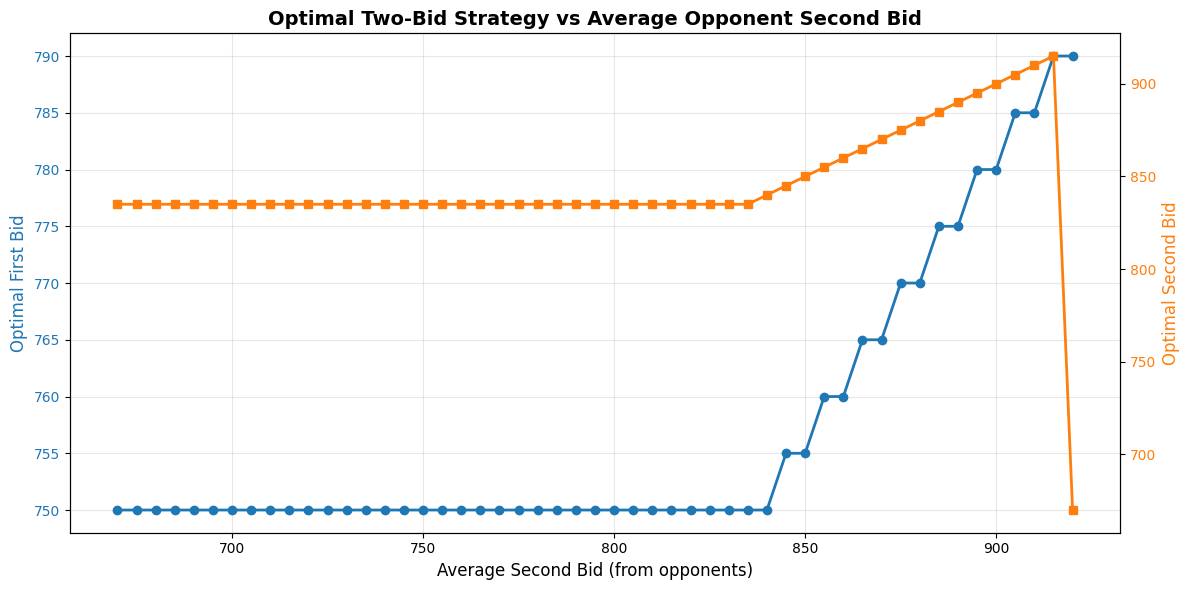

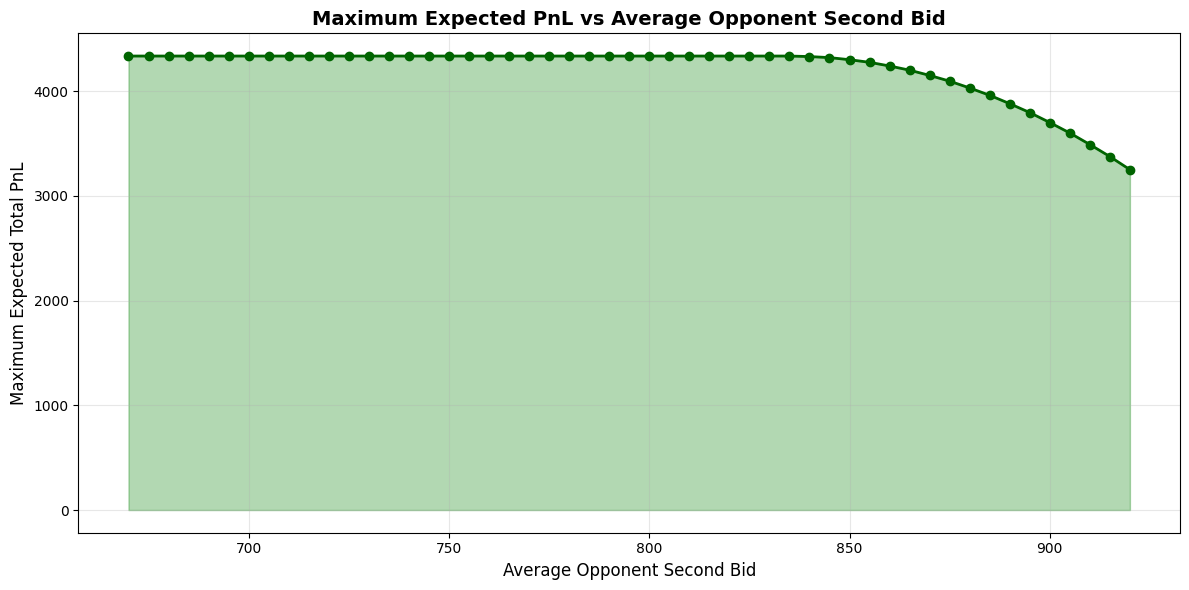

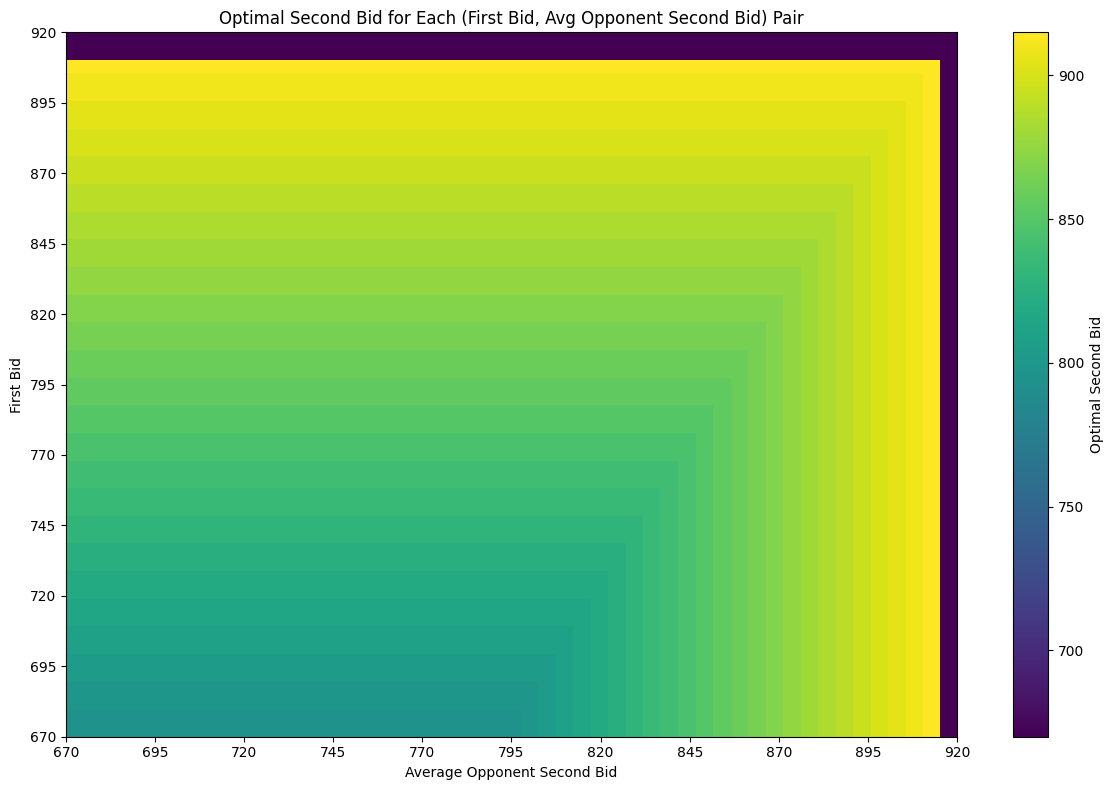

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Two-bid strategy analysis - corrected logic
# First bid: trade with counterparties with reserve <= first_bid
# Second bid: trade with counterparties with reserve in (first_bid, second_bid]
#   - if second_bid > mean(others' second bids): trade at bid (no penalty)
#   - if second_bid <= mean(others' second bids): trade at bid with penalty ((920-avg)/(920-bid))^3

reserves = np.arange(670, 925, 5)
bid_grid = np.arange(670, 925, 5)
n = len(reserves)

def calculate_two_bid_pnl(first_bid, second_bid, avg_second_bid, reserves):
    """
    Calculate expected PnL for two-bid strategy.
    
    First bid: trade with all counterparties with reserve <= first_bid
    Second bid: trade with counterparties with reserve in (first_bid, second_bid]
               - Apply penalty if second_bid <= avg_second_bid
    """
    # First bid trades: all reserves <= first_bid
    first_bid_count = np.sum(reserves <= first_bid)
    first_bid_pnl = first_bid_count * (920 - first_bid)
    
    # Second bid trades: reserves in (first_bid, second_bid]
    # Only counterparties with reserve in this range will accept
    second_bid_mask = (reserves > first_bid) & (reserves <= second_bid)
    second_bid_volume = np.sum(second_bid_mask)
    
    if second_bid_volume > 0:
        second_bid_base_pnl = second_bid_volume * (920 - second_bid)
        
        # Apply penalty if second_bid <= avg_second_bid
        if second_bid > avg_second_bid:
            penalty = 1.0  # No penalty
        else:
            penalty = ((920 - avg_second_bid) / (920 - second_bid)) ** 3
            penalty = min(1.0, penalty)
    else:
        second_bid_base_pnl = 0
        penalty = 1.0
    
    second_bid_pnl = second_bid_base_pnl * penalty
    
    total_pnl = first_bid_pnl + second_bid_pnl
    return total_pnl, first_bid_pnl, second_bid_pnl, second_bid_volume

# For each avg_second_bid, find the optimal (first_bid, second_bid) combination
avg_second_bids = np.arange(670, 925, 5)

optimal_first_bids = []
optimal_second_bids = []
max_pnls = []

print("=== Optimal Strategy by Average Opponent Second Bid ===")
for avg_sb in avg_second_bids:
    best_total_pnl = -np.inf
    best_first = None
    best_second = None
    
    for fb in bid_grid:
        for sb in bid_grid:
            total_pnl, _, _, _ = calculate_two_bid_pnl(fb, sb, avg_sb, reserves)
            if total_pnl > best_total_pnl:
                best_total_pnl = total_pnl
                best_first = fb
                best_second = sb
    
    optimal_first_bids.append(best_first)
    optimal_second_bids.append(best_second)
    max_pnls.append(best_total_pnl)

# Print results
print(f"{'Avg 2nd Bid':>12} {'Opt 1st Bid':>12} {'Opt 2nd Bid':>12} {'Max PnL':>12}")
print("-" * 50)
for i in range(0, len(avg_second_bids), 2):
    print(f"{avg_second_bids[i]:>12.0f} {optimal_first_bids[i]:>12.0f} {optimal_second_bids[i]:>12.0f} {max_pnls[i]:>12.2f}")

# Plot 1: Optimal bids vs average second bid
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Average Second Bid (from opponents)', fontsize=12)
ax1.set_ylabel('Optimal First Bid', color=color, fontsize=12)
line1 = ax1.plot(avg_second_bids, optimal_first_bids, marker='o', color=color, label='Optimal First Bid', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Optimal Second Bid', color=color, fontsize=12)
line2 = ax2.plot(avg_second_bids, optimal_second_bids, marker='s', color=color, label='Optimal Second Bid', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimal Two-Bid Strategy vs Average Opponent Second Bid', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Plot 2: PnL vs average second bid
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(avg_second_bids, max_pnls, marker='o', linewidth=2, markersize=6, color='darkgreen')
ax.fill_between(avg_second_bids, max_pnls, alpha=0.3, color='green')
ax.set_xlabel('Average Opponent Second Bid', fontsize=12)
ax.set_ylabel('Maximum Expected Total PnL', fontsize=12)
ax.set_title('Maximum Expected PnL vs Average Opponent Second Bid', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Heatmap - for each (first_bid, avg_second_bid), show optimal second_bid
heatmap_optimal_second = np.zeros((len(bid_grid), len(avg_second_bids)))

for i, fb in enumerate(bid_grid):
    for j, avg_sb in enumerate(avg_second_bids):
        best_sb_pnl = -np.inf
        best_sb = bid_grid[0]
        
        for sb in bid_grid:
            total_pnl, _, _, _ = calculate_two_bid_pnl(fb, sb, avg_sb, reserves)
            if total_pnl > best_sb_pnl:
                best_sb_pnl = total_pnl
                best_sb = sb
        
        heatmap_optimal_second[i, j] = best_sb

plt.figure(figsize=(12, 8))
img = plt.imshow(
    heatmap_optimal_second,
    origin='lower',
    aspect='auto',
    extent=[avg_second_bids.min(), avg_second_bids.max(), bid_grid.min(), bid_grid.max()],
    cmap='viridis'
)
plt.colorbar(img, label='Optimal Second Bid')
plt.title('Optimal Second Bid for Each (First Bid, Avg Opponent Second Bid) Pair')
plt.xlabel('Average Opponent Second Bid')
plt.ylabel('First Bid')
plt.xticks(np.arange(670, 925, 25))
plt.yticks(np.arange(670, 925, 25))
plt.tight_layout()
plt.show()

In [5]:
import ipywidgets as widgets
from ipywidgets import interact, IntSlider
import numpy as np
import matplotlib.pyplot as plt

reserves = np.arange(670, 925, 5)
bid_grid = np.arange(670, 925, 5)

def plot_second_bid_profit(first_bid, avg_second_bid):
    """
    Plot second bid profit as a function of second bid value.
    Shows both the base profit and the penalized profit.
    """
    second_bid_values = bid_grid
    base_profits = []
    penalized_profits = []
    optimal_second_bid = None
    max_profit = -np.inf
    
    for sb in second_bid_values:
        # Count counterparties with reserve in (first_bid, second_bid]
        second_bid_count = np.sum((reserves > first_bid) & (reserves <= sb))
        
        if second_bid_count > 0:
            base_pnl = second_bid_count * (920 - sb)
            
            # Apply penalty if second_bid <= avg_second_bid
            if sb > avg_second_bid or avg_second_bid >= 920:
                penalty = 1.0
            else:
                penalty = ((920 - avg_second_bid) / (920 - sb)) ** 3
                penalty = min(1.0, penalty)
            
            penalized_pnl = base_pnl * penalty
        else:
            base_pnl = 0
            penalized_pnl = 0
        
        base_profits.append(base_pnl)
        penalized_profits.append(penalized_pnl)
        
        if penalized_pnl > max_profit:
            max_profit = penalized_pnl
            optimal_second_bid = sb
    
    # Calculate first bid profit
    first_bid_count = np.sum(reserves <= first_bid)
    first_bid_profit = first_bid_count * (920 - first_bid)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(second_bid_values, base_profits, label='Base Profit (no penalty)', 
            linewidth=2.5, marker='o', markersize=5, color='skyblue')
    ax.plot(second_bid_values, penalized_profits, label='Profit with Penalty', 
            linewidth=2.5, marker='s', markersize=5, color='darkblue')
    
    # Mark the optimal second bid
    if optimal_second_bid is not None:
        optimal_idx = np.where(second_bid_values == optimal_second_bid)[0][0]
        ax.plot(optimal_second_bid, penalized_profits[optimal_idx], 'r*', 
                markersize=25, label=f'Optimal 2nd Bid = {optimal_second_bid}', zorder=5)
    
    # Mark the average second bid from opponents
    ax.axvline(avg_second_bid, color='gray', linestyle='--', linewidth=2.5, 
               label=f'Avg Opponent 2nd Bid = {avg_second_bid}', alpha=0.7)
    
    ax.set_xlabel('Second Bid', fontsize=12, fontweight='bold')
    ax.set_ylabel('PnL from Second Bid', fontsize=12, fontweight='bold')
    ax.set_title(f'Second Bid Profitability (First Bid = {first_bid}, Avg Opponent 2nd Bid = {avg_second_bid})', 
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(alpha=0.3)
    
    # Add text box with summary stats
    total_pnl = first_bid_profit + max_profit
    textstr = f'First Bid Profit: {first_bid_profit:.0f}\nOpt 2nd Bid Profit: {max_profit:.0f}\nTotal: {total_pnl:.0f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props, family='monospace')
    
    plt.tight_layout()
    plt.show()

# Create interactive widget
interact(
    plot_second_bid_profit,
    first_bid=IntSlider(value=750, min=670, max=915, step=5, description='First Bid:'),
    avg_second_bid=IntSlider(value=800, min=670, max=920, step=5, description='Avg 2nd Bid:')
)

interactive(children=(IntSlider(value=750, description='First Bid:', max=915, min=670, step=5), IntSlider(valu…

<function __main__.plot_second_bid_profit(first_bid, avg_second_bid)>